In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
from cifar10_dataset import CIFAR10Dataset
from torch.utils.data import DataLoader
from resnet import ResNet
import torch.nn as nn
import torch
from tqdm.auto import tqdm
from utils import plot_confusion_matrix

In [14]:
ROOT = Path("C:/Users/cleme/OneDrive/PostDoc/data/cifar10")
train_dataset = CIFAR10Dataset(root_dir=ROOT, split="train")
val_dataset = CIFAR10Dataset(root_dir=ROOT, split="val")
test_dataset = CIFAR10Dataset(root_dir=ROOT, split="test")

train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_dataloader = DataLoader(val_dataset, batch_size=256, shuffle=False, persistent_workers=True, num_workers=2, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=256, shuffle=False)

c:\Users\cleme\miniconda3\envs\torch\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.3'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
c:\Users\cleme\miniconda3\envs\torch\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


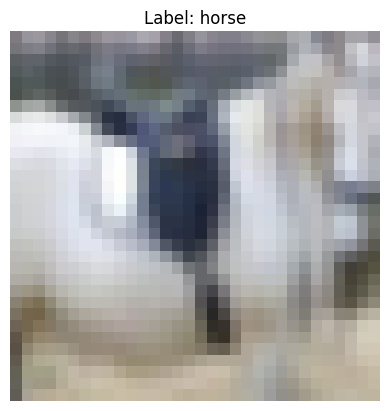

In [37]:
train_dataset.show(1)

In [5]:
batch = next(iter(train_dataloader))

In [8]:
imgs, labels = batch

In [ ]:
model = ResNet(num_classes=10, in_chans=3).cuda()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 1/10 - Validation:   0%|          | 0/14 [00:05<?, ?it/s]

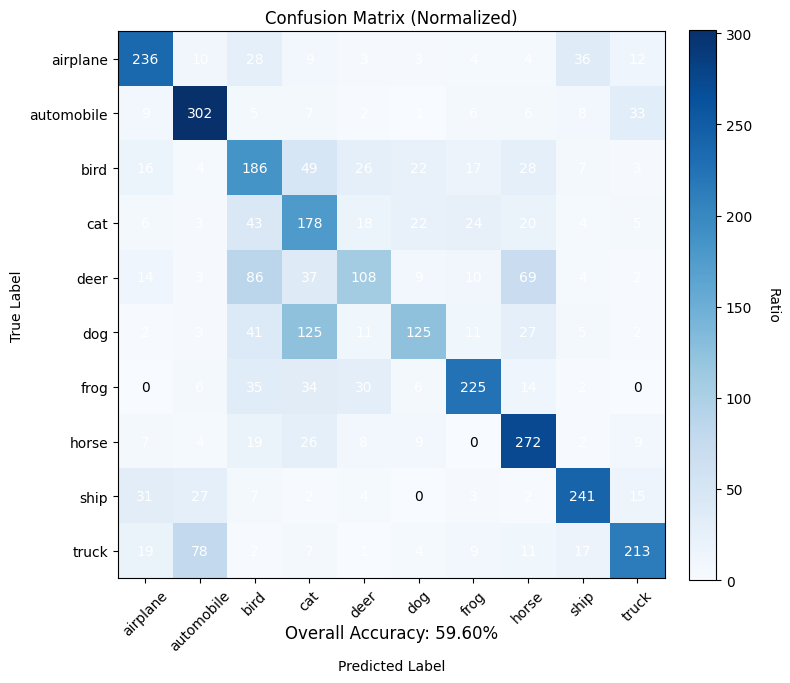

Epoch 1/10 - Training Loss: 1.3414


Epoch 2/10 - Validation:   0%|          | 0/14 [00:00<?, ?it/s]

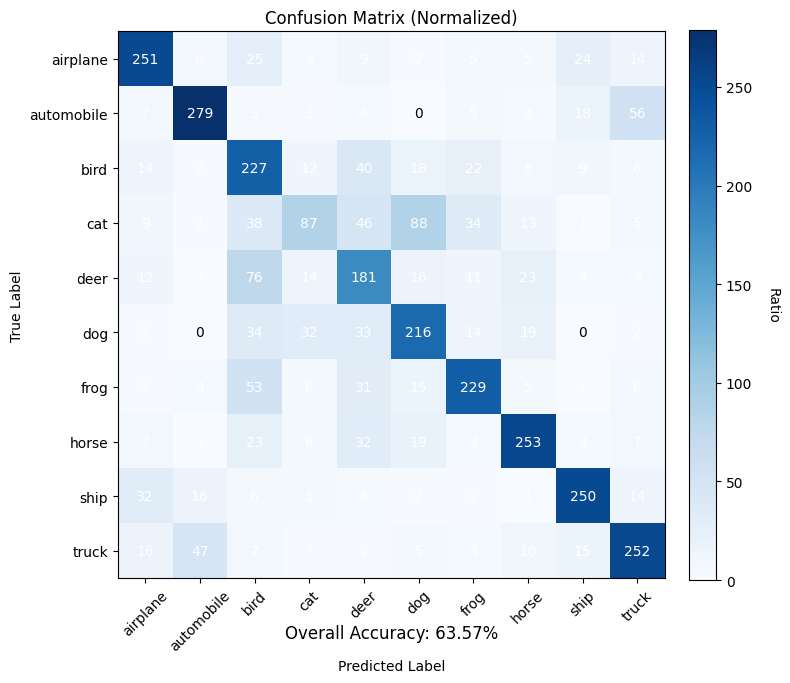

Epoch 2/10 - Training Loss: 0.9589


Epoch 3/10 - Validation:   0%|          | 0/14 [00:00<?, ?it/s]

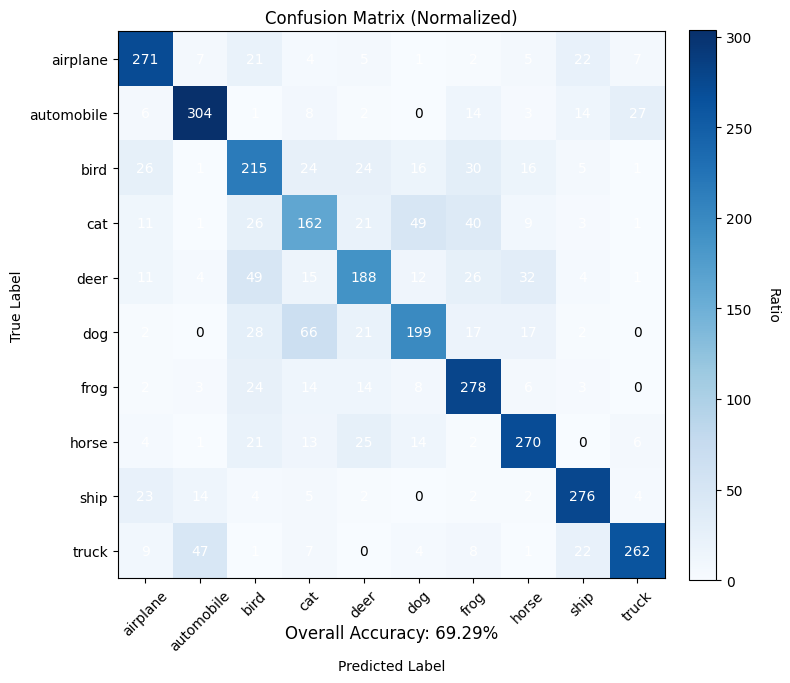

Epoch 3/10 - Training Loss: 0.8024


Epoch 4/10 - Validation:   0%|          | 0/14 [00:00<?, ?it/s]

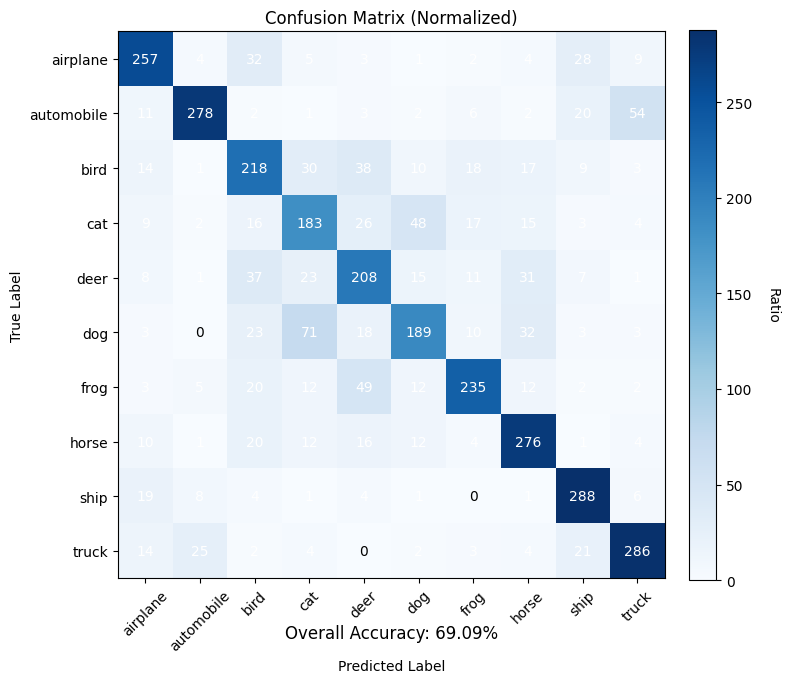

Epoch 4/10 - Training Loss: 0.6652


Epoch 5/10 - Validation:   0%|          | 0/14 [00:00<?, ?it/s]

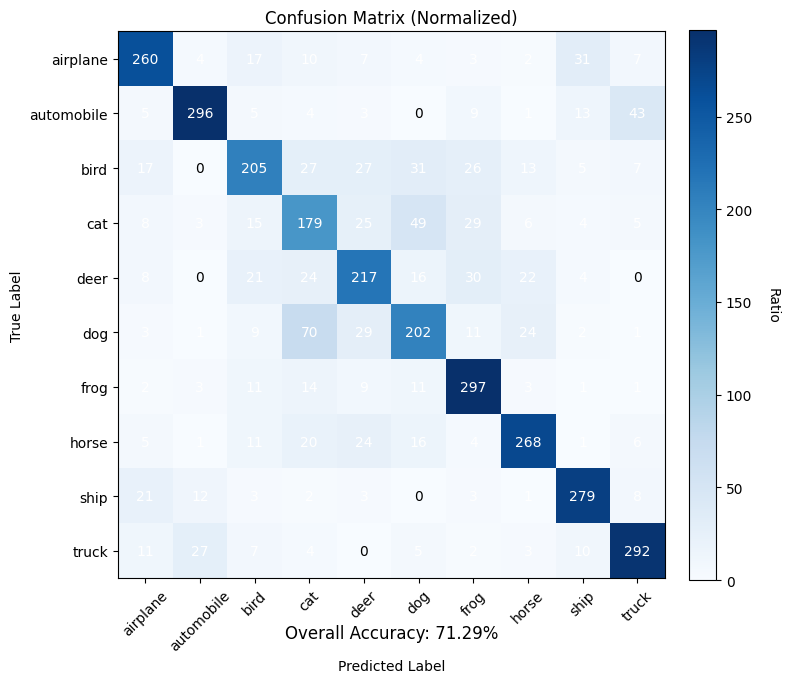

Epoch 5/10 - Training Loss: 0.5619


Epoch 6/10 - Validation:   0%|          | 0/14 [00:00<?, ?it/s]

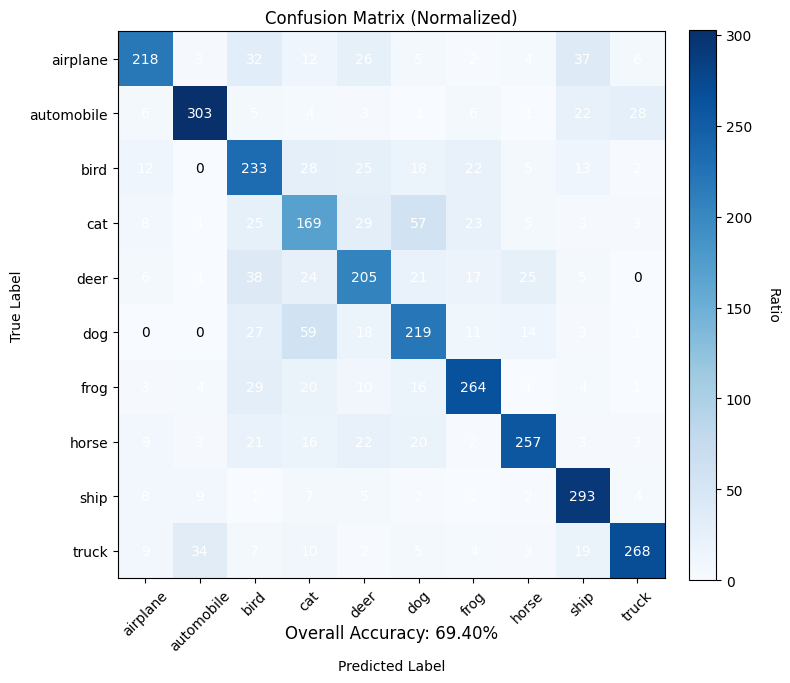

Epoch 6/10 - Training Loss: 0.4392


Epoch 7/10 - Validation:   0%|          | 0/14 [00:00<?, ?it/s]

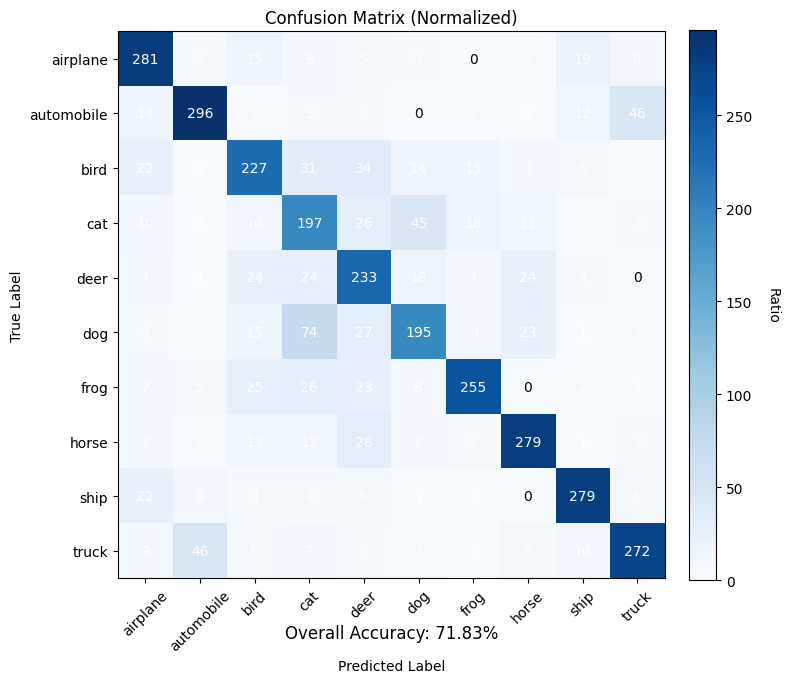

Epoch 7/10 - Training Loss: 0.3828


Epoch 8/10 - Validation:   0%|          | 0/14 [00:00<?, ?it/s]

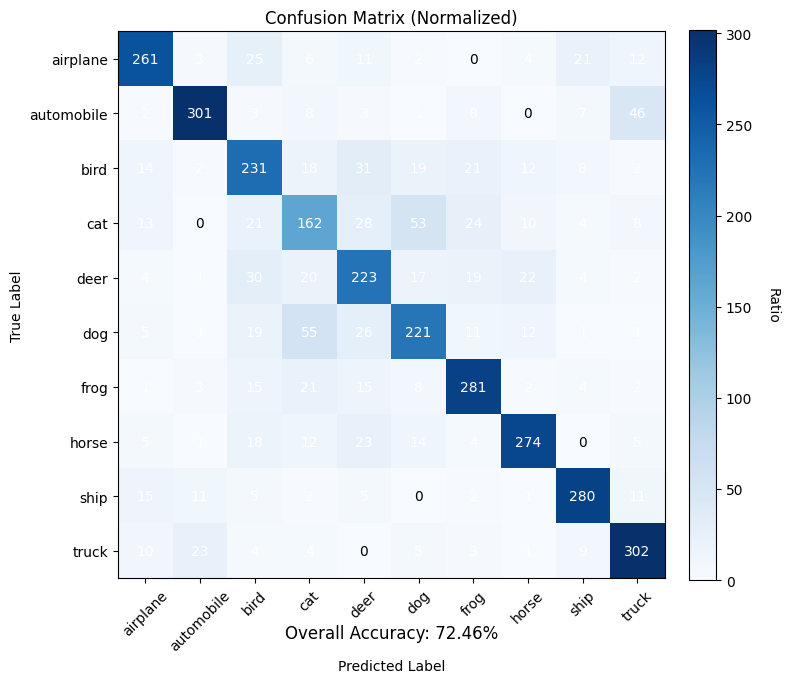

Epoch 8/10 - Training Loss: 0.2650


Epoch 9/10 - Validation:   0%|          | 0/14 [00:00<?, ?it/s]

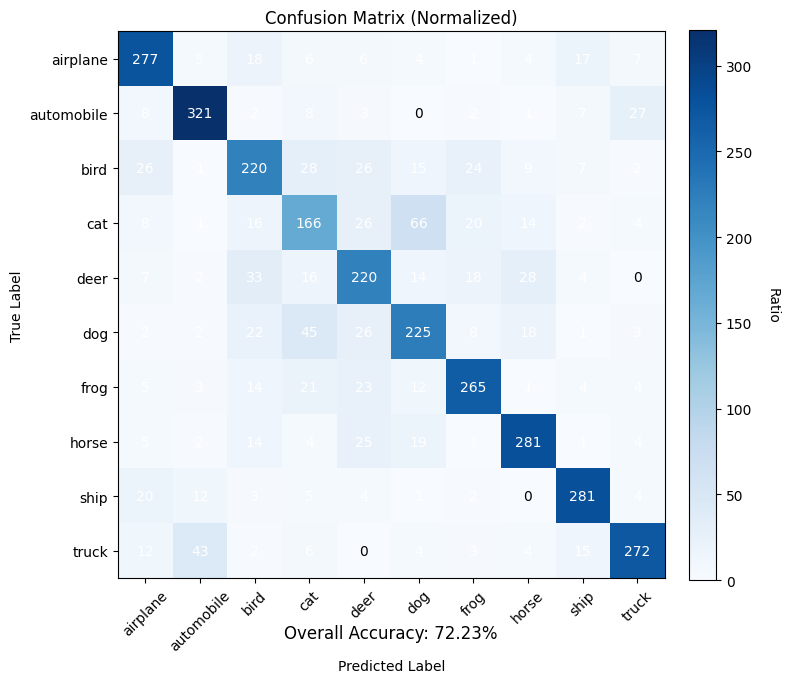

Epoch 9/10 - Training Loss: 0.1963


Epoch 10/10 - Validation:   0%|          | 0/14 [00:00<?, ?it/s]

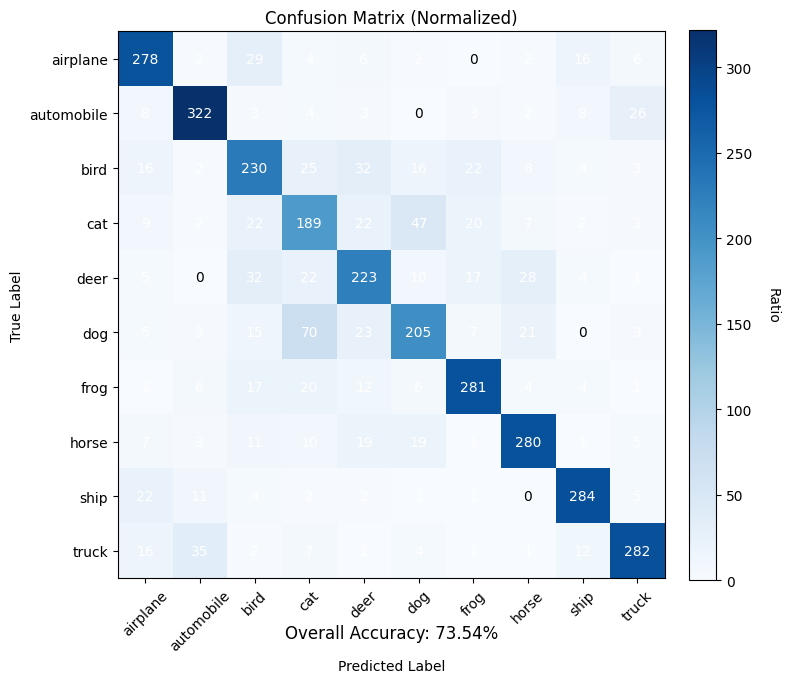

Epoch 10/10 - Training Loss: 0.1700


In [ ]:
NUM_EPOCHS = 10
for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    for images, labels in train_dataloader:
        images, labels = images.cuda(), labels.cuda()
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    
    # Initialize the confusion matrix
    confMatrix = torch.zeros(10, 10, dtype=torch.float32, device='cuda')
    model.eval()
    for images, labels in tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Validation"):
        images, labels = images.cuda(), labels.cuda()
        
        with torch.no_grad():
            outputs = model(images) # BxC
            loss = loss_fn(outputs, labels)
            preds = torch.argmax(outputs, dim=1) # B
            # To One-Hot encode the labels and predictions
            labels_one_hot = torch.nn.functional.one_hot(labels, num_classes=10).to(torch.float32)
            preds_one_hot = torch.nn.functional.one_hot(preds, num_classes=10).to(torch.float32)
            confMatrix += torch.matmul(labels_one_hot.T, preds_one_hot)
            
        
    plot_confusion_matrix(confMatrix.long().cpu().numpy(), class_names=train_dataset.classes)    

    train_loss /= len(train_dataloader.dataset)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Training Loss: {train_loss:.4f}")



In [21]:

# Per class accuracy
total_samples = confMatrix.sum()
tp = torch.diag(confMatrix)
fp = confMatrix.sum(dim=0) - tp
fn = confMatrix.sum(dim=1) - tp
tn = total_samples - (tp + fp + fn)

accuracy_per_class = (tp + tn) / total_samples
accuracy_per_class
global_acc = torch.diag(confMatrix).sum() / confMatrix.sum()
print(f"Global Accuracy: {global_acc:.4f}")
print(f"Per Class Accuracy: {accuracy_per_class.cpu().numpy()}")

Global Accuracy: 0.7354
Per Class Accuracy: [0.9554286  0.9654286  0.92485714 0.91485715 0.9317143  0.928
 0.95914286 0.9574286  0.97171426 0.9622857 ]


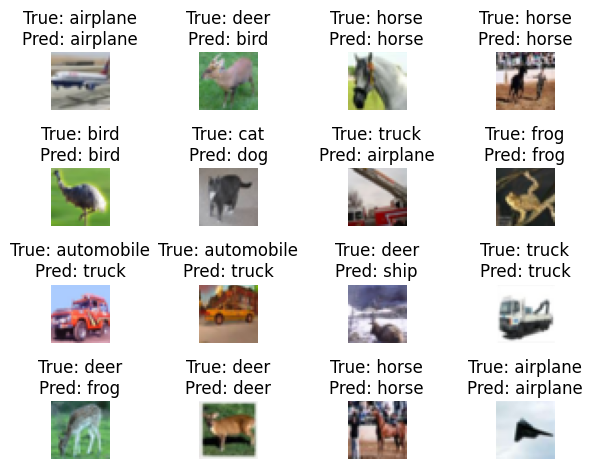

In [22]:
# Let's plot a batch of images with their predicted and true labels
import matplotlib.pyplot as plt
def plot_images_with_predictions(images, labels, preds, class_names):
    plt.figure()
    for i in range(min(16, len(images))):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].permute(1, 2, 0).cpu().numpy())
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
        plt.axis('off')
    plt.subplots_adjust(wspace=0,  hspace=0)
    plt.tight_layout()
    plt.show()

# Get a batch of validation data
images, labels = next(iter(val_dataloader))
images, labels = images.cuda(), labels.cuda()
with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)
plot_images_with_predictions(images, labels, preds, class_names=train_dataset.classes)